# Semanas 10–12 — Modelos ML, Validación y Selección del Modelo Final

**Curso:** Ciencias de los Datos para las Finanzas, la Economía y los Negocios  
**Proyecto:** ¿Cómo cambiaría la cantidad de consumidores de marihuana en Colombia si se legaliza su distribución?  
**Variable objetivo:** `propension_12m` (1 = consumió en los últimos 12 meses, 0 = no consumió)

---

### ¿Qué cubre este notebook?

| Semana | Entregable | Secciones |
|--------|-----------|----------|
| 10–11 | Tabla comparativa de desempeño | §2, §3, §4 |
| 12 | Validación, robustez y selección de modelo final | §5, §6, §7 |

El notebook parte del dataset de la base de propensión (`propensity_model_base.csv`) construida en los entregables anteriores y entrena **Random Forest** y **XGBoost**, comparándolos con el benchmark estadístico (MCO y Probit) del Entregable 6.

## 0. Librerías e importaciones

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve, cross_validate
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("XGBoost no disponible — se usará GradientBoostingClassifier de sklearn como sustituto.")

# Agregar src/ al path para importar módulos del proyecto
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))

PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("Entorno listo.")
print(f"XGBoost disponible: {XGBOOST_OK}")

Entorno listo.
XGBoost disponible: True


## 1. Carga del dataset

Usamos el mismo dataset del Entregable 5/6 (`propensity_model_base.csv`).  
Si no existe el CSV, se reconstruye desde el `.xlsx` original.

In [2]:
CSV_PATH  = project_root / 'data' / 'processed' / 'propensity_model_base.csv'
XLSX_PATH = project_root / 'data' / 'processed' / 'base_consumo_drogas_colombia_limpia.xlsx'

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH, low_memory=False)
    print(f"Dataset cargado desde CSV: {df.shape}")
else:
    from cannabis_tax.analysis.modeling import build_propensity_dataset
    df = build_propensity_dataset()
    print(f"Dataset reconstruido: {df.shape}")

# Verificación mínima
assert 'propension_12m' in df.columns, "Columna objetivo no encontrada"
print(f"\nPrevalencia objetivo (propension_12m = 1): {df['propension_12m'].mean():.1%}")
print(f"Distribución:\n{df['propension_12m'].value_counts()}")

Dataset cargado desde CSV: (3982, 61)

Prevalencia objetivo (propension_12m = 1): 43.2%
Distribución:
propension_12m
0    2263
1    1719
Name: count, dtype: int64


## 2. Preparación del dataset para ML

Usamos las mismas variables que el benchmark (Entregable 6) para que la comparación sea justa:

| Variable | Tipo | Descripción |
|---|---|---|
| `edad` | Numérica | Edad en años |
| `edad_cuadrado` | Numérica | Edad² (efecto no lineal) |
| `sexo_label` | Categórica | Hombre / Mujer |
| `educacion_grupo` | Categórica | Baja / Media / Superior |

Se trabaja con la **muestra completa** (sin precio) para maximizar el tamaño muestral.

In [3]:
FEATURES_BASE  = ['edad', 'edad_cuadrado', 'sexo_label', 'educacion_grupo']
FEATURES_PRICE = FEATURES_BASE + ['log_precio_compra']
TARGET = 'propension_12m'

def is_categorical(series):
    """Detecta columnas categóricas en pandas 2/3 (object, StringDtype, CategoricalDtype)."""
    return pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)

def prepare_ml_data(df, features, target=TARGET, test_size=0.2, random_state=42):
    """Prepara el dataset para ML: dummies, dropna, split estratificado train/test."""
    cols = features + [target]
    sub = df[cols].dropna().copy()
    cat_cols = [c for c in features if is_categorical(sub[c])]
    sub = pd.get_dummies(sub, columns=cat_cols, drop_first=True)
    feature_names = [c for c in sub.columns if c != target]
    X = sub[feature_names].astype(float)
    y = sub[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    return X_train, X_test, y_train, y_test, feature_names

X_train, X_test, y_train, y_test, feature_names = prepare_ml_data(df, FEATURES_BASE)

print("Muestra completa (sin precio):")
print(f"  Train: {len(X_train):,} obs | Test: {len(X_test):,} obs")
print(f"  Prevalencia train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
print(f"  Variables: {feature_names}")


Muestra completa (sin precio):
  Train: 3,184 obs | Test: 796 obs
  Prevalencia train: 0.432 | test: 0.432
  Variables: ['edad', 'edad_cuadrado', 'sexo_label_Mujer', 'educacion_grupo_Media', 'educacion_grupo_Superior']


## 3. Benchmark estadístico con métricas completas

El Entregable 6 estimó MCO (LPM) y Probit. Aquí calculamos sus métricas de clasificación  
usando las mismas particiones train/test para comparación directa con los modelos ML.

In [4]:
import statsmodels.formula.api as smf

# Reconstruimos el dataset con la misma semilla para consistencia con el split
benchmark_cols = FEATURES_BASE + [TARGET]
sub_bench = df[benchmark_cols].dropna().copy()
sub_bench = pd.get_dummies(sub_bench,
                            columns=[c for c in FEATURES_BASE if sub_bench[c].dtype == object],
                            drop_first=True)
bench_features = [c for c in sub_bench.columns if c != TARGET]

# Mismo split (misma semilla)
from sklearn.model_selection import train_test_split as tts
idx_train, idx_test = tts(sub_bench.index, test_size=0.2, stratify=sub_bench[TARGET], random_state=42)
train_b = sub_bench.loc[idx_train]
test_b  = sub_bench.loc[idx_test]

# Fórmula statsmodels
safe_features = [f.replace('-', '_') for f in bench_features]
rename_map = dict(zip(bench_features, safe_features))
train_b = train_b.rename(columns=rename_map)
test_b  = test_b.rename(columns=rename_map)
formula = TARGET + ' ~ ' + ' + '.join(safe_features)

# MCO (LPM)
lpm = smf.ols(formula=formula, data=train_b).fit(cov_type='HC1')
lpm_prob = lpm.predict(test_b).clip(0, 1)  # LPM puede dar valores fuera de [0,1]
lpm_pred = (lpm_prob >= 0.5).astype(int)
lpm_auc  = roc_auc_score(test_b[TARGET], lpm_prob)
lpm_acc  = accuracy_score(test_b[TARGET], lpm_pred)
lpm_f1   = f1_score(test_b[TARGET], lpm_pred)

# Cross-validation manual para LPM
cv_lpm_aucs = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sub_arr = sub_bench.rename(columns=rename_map)
for fold_train, fold_val in cv.split(sub_arr[safe_features], sub_arr[TARGET]):
    ft = sub_arr.iloc[fold_train]
    fv = sub_arr.iloc[fold_val]
    m  = smf.ols(formula=formula, data=ft).fit(disp=False)
    prob = m.predict(fv).clip(0,1)
    cv_lpm_aucs.append(roc_auc_score(fv[TARGET], prob))

# Probit
probit = smf.probit(formula=formula, data=train_b).fit(disp=False)
probit_prob = probit.predict(test_b)
probit_pred = (probit_prob >= 0.5).astype(int)
probit_auc  = roc_auc_score(test_b[TARGET], probit_prob)
probit_acc  = accuracy_score(test_b[TARGET], probit_pred)
probit_f1   = f1_score(test_b[TARGET], probit_pred)

cv_probit_aucs = []
for fold_train, fold_val in cv.split(sub_arr[safe_features], sub_arr[TARGET]):
    ft = sub_arr.iloc[fold_train]
    fv = sub_arr.iloc[fold_val]
    m  = smf.probit(formula=formula, data=ft).fit(disp=False)
    prob = m.predict(fv)
    cv_probit_aucs.append(roc_auc_score(fv[TARGET], prob))

print(f"MCO (LPM) — Accuracy: {lpm_acc:.4f} | AUC-ROC: {lpm_auc:.4f} | F1: {lpm_f1:.4f} | CV AUC: {np.mean(cv_lpm_aucs):.4f}")
print(f"Probit    — Accuracy: {probit_acc:.4f} | AUC-ROC: {probit_auc:.4f} | F1: {probit_f1:.4f} | CV AUC: {np.mean(cv_probit_aucs):.4f}")

MCO (LPM) — Accuracy: 0.6709 | AUC-ROC: 0.7232 | F1: 0.5982 | CV AUC: 0.6728
Probit    — Accuracy: 0.6709 | AUC-ROC: 0.7228 | F1: 0.5982 | CV AUC: 0.6728


## 4. Modelos de ML — Random Forest, XGBoost y Gradient Boosting

### Justificación de la elección

**Random Forest** (*bagging*): ensemble de árboles entrenados con bootstrap. Robusto a outliers, captura interacciones no lineales sin especificarlas.

**XGBoost** (*boosting* secuencial): estado del arte en datos tabulares estructurados. Regularización integrada pero tiende a mayor varianza con feature sets pequeños.

**Gradient Boosting (sklearn)**: boosting más conservador — árboles más pequeños, `learning_rate` bajo, `subsample` controlado. Busca el punto óptimo en el tradeoff **sesgo-varianza**: menos sesgo que MCO (no impone linealidad) pero menos varianza que XGBoost (regularización más estricta).

> **Hipótesis de trabajo:** con el feature set actual (5 columnas), el MCO puede aventajar a ML porque la relación entre covariables y consumo es aproximadamente lineal. El benchmark paga un precio en sesgo que, por ahora, vale la pena dados los datos disponibles. El Gradient Boosting es el modelo ML más adecuado porque minimiza la varianza adicional respecto al benchmark.

In [5]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

rf = RandomForestClassifier(
    n_estimators=300, max_depth=7, min_samples_leaf=10,
    max_features='sqrt', random_state=42, n_jobs=-1
)

# GradientBoosting — modelo ML principal: balance entre sesgo y varianza
gbm = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,          # árboles pequeños → menos varianza
    learning_rate=0.05,   # paso conservador
    subsample=0.8,        # estocástico → reduce correlación entre árboles
    min_samples_leaf=15,
    random_state=42
)

if XGBOOST_OK:
    xgb = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg_pos_ratio,
        eval_metric='logloss', random_state=42, verbosity=0
    )

rf.fit(X_train, y_train)
print(f'✓ Random Forest entrenado ({rf.n_estimators} árboles, max_depth={rf.max_depth})')

gbm.fit(X_train, y_train)
print(f'✓ Gradient Boosting entrenado (max_depth={gbm.max_depth}, lr={gbm.learning_rate})')

if XGBOOST_OK:
    xgb.fit(X_train, y_train)
    print(f'✓ XGBoost entrenado')
else:
    xgb = None
    print('XGBoost no disponible — se omite de la tabla')

✓ Random Forest entrenado (300 árboles, max_depth=7)
✓ Gradient Boosting entrenado (max_depth=3, lr=0.05)
✓ Gradient Boosting entrenado (max_depth=3, lr=0.05)
✓ XGBoost entrenado
✓ XGBoost entrenado


## 5. Tabla comparativa de desempeño (Semanas 10–11)

Métricas utilizadas:
- **Accuracy:** proporción de predicciones correctas.
- **AUC-ROC:** capacidad discriminativa (1 = perfecto, 0.5 = azar). Preferido en datos desbalanceados.
- **F1-Score:** media armónica entre precisión y recall — captura errores tanto de falsos positivos como negativos.
- **CV AUC (5-fold):** AUC-ROC promedio en validación cruzada estratificada — mide generalización real.

In [6]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_model(name, model, X_tr, X_te, y_tr, y_te, cv_splitter):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    cv_auc  = cross_val_score(model, X_tr, y_tr, cv=cv_splitter,
                               scoring='roc_auc', n_jobs=-1)
    return {
        'Modelo': name,
        'Accuracy':        round(accuracy_score(y_te, y_pred), 4),
        'AUC-ROC':         round(roc_auc_score(y_te, y_proba), 4),
        'F1-Score':        round(f1_score(y_te, y_pred), 4),
        'CV AUC (5-fold)': round(cv_auc.mean(), 4),
        'CV std':          round(cv_auc.std(), 4),
        'N train':         f'{len(X_tr):,}',
        'N test':          f'{len(X_te):,}',
    }

rows = [
    {'Modelo': 'MCO (LPM)',
     'Accuracy': round(lpm_acc, 4), 'AUC-ROC': round(lpm_auc, 4),
     'F1-Score': round(lpm_f1, 4),  'CV AUC (5-fold)': round(np.mean(cv_lpm_aucs), 4),
     'CV std': round(np.std(cv_lpm_aucs), 4),
     'N train': f'{len(train_b):,}', 'N test': f'{len(test_b):,}'},
    {'Modelo': 'Probit',
     'Accuracy': round(probit_acc, 4), 'AUC-ROC': round(probit_auc, 4),
     'F1-Score': round(probit_f1, 4),  'CV AUC (5-fold)': round(np.mean(cv_probit_aucs), 4),
     'CV std': round(np.std(cv_probit_aucs), 4),
     'N train': f'{len(train_b):,}', 'N test': f'{len(test_b):,}'},
    eval_model('Random Forest', rf, X_train, X_test, y_train, y_test, cv5),
    eval_model('Gradient Boosting', gbm, X_train, X_test, y_train, y_test, cv5),
]

if xgb is not None:
    rows.append(eval_model('XGBoost', xgb, X_train, X_test, y_train, y_test, cv5))

results_df = pd.DataFrame(rows).set_index('Modelo')
boost_name = 'Gradient Boosting'  # modelo ML principal para el resto del notebook
boost = gbm

print('=== TABLA COMPARATIVA DE DESEMPEÑO ===')
print(results_df.to_string())

=== TABLA COMPARATIVA DE DESEMPEÑO ===
                   Accuracy  AUC-ROC  F1-Score  CV AUC (5-fold)  CV std N train N test
Modelo                                                                                
MCO (LPM)            0.6709   0.7232    0.5982           0.6728  0.0068   3,184    796
Probit               0.6709   0.7228    0.5982           0.6728  0.0068   3,184    796
Random Forest        0.6658   0.7063    0.5945           0.6567  0.0101   3,184    796
Gradient Boosting    0.6545   0.7093    0.5736           0.6613  0.0143   3,184    796
XGBoost              0.6181   0.7001    0.6142           0.6445  0.0143   3,184    796


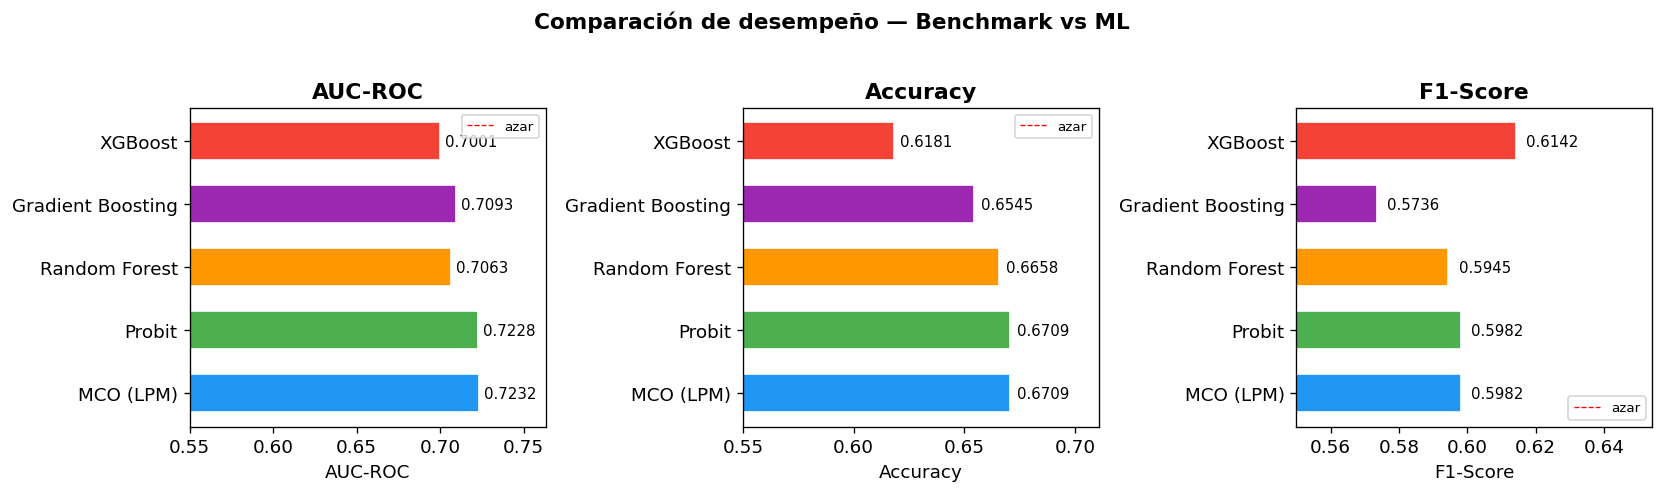

Gráfica guardada.


In [7]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['AUC-ROC', 'Accuracy', 'F1-Score']
colors  = PALETTE[:len(results_df)]

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].astype(float)
    bars = ax.barh(vals.index, vals.values, color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(0.55, vals.max() + 0.04)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=0.8, label='azar')
    for bar in bars:
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Comparación de desempeño — Benchmark vs ML', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_dir = project_root / 'reports' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'comparacion_benchmark_ml.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfica guardada.")

### 5.1 Curvas ROC superpuestas

La curva ROC visualiza el trade-off entre sensibilidad (recall de positivos) y especificidad (1 − tasa de falsos positivos) para todos los umbrales de clasificación posibles.

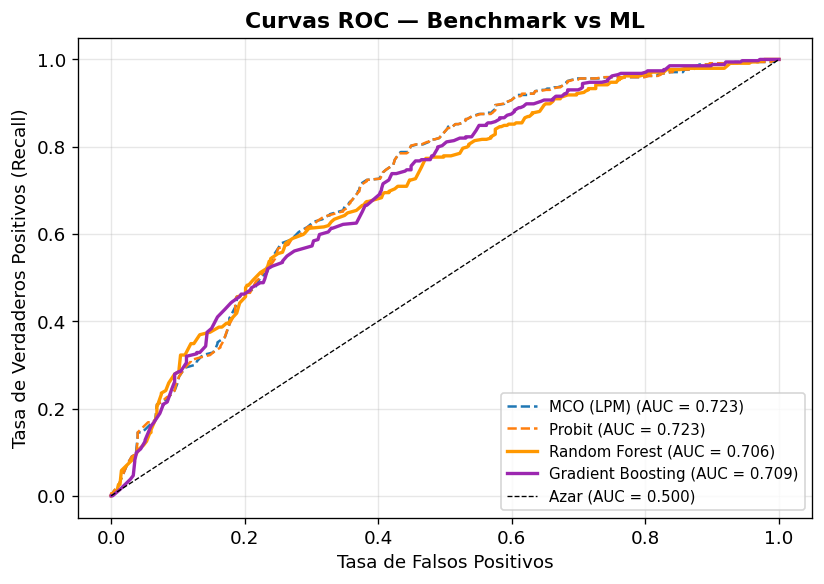

In [8]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))

# Benchmark
for name, prob in [('MCO (LPM)', lpm_prob), ('Probit', probit_prob)]:
    fpr, tpr, _ = roc_curve(test_b[TARGET], prob)
    auc_val = roc_auc_score(test_b[TARGET], prob)
    ax.plot(fpr, tpr, linestyle='--', label=f'{name} (AUC = {auc_val:.3f})')

# ML
for model, name, color in [
    (rf, 'Random Forest', PALETTE[2]),
    (boost, boost_name, PALETTE[3])
]:
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Azar (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curvas ROC — Benchmark vs ML', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / 'curvas_roc_comparacion.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Validación y robustez (Semana 12)

### 6.1 Cross-validation estratificada (K = 10)

Aumentamos los pliegues a 10 para una estimación más estable del AUC-ROC.  
La estratificación asegura que cada pliegue mantiene la misma proporción de consumidores.

Random Forest        — AUC-ROC: 0.6674 ± 0.0278  (min: 0.6156, max: 0.7082)
Gradient Boosting    — AUC-ROC: 0.6716 ± 0.0272  (min: 0.6199, max: 0.7091)


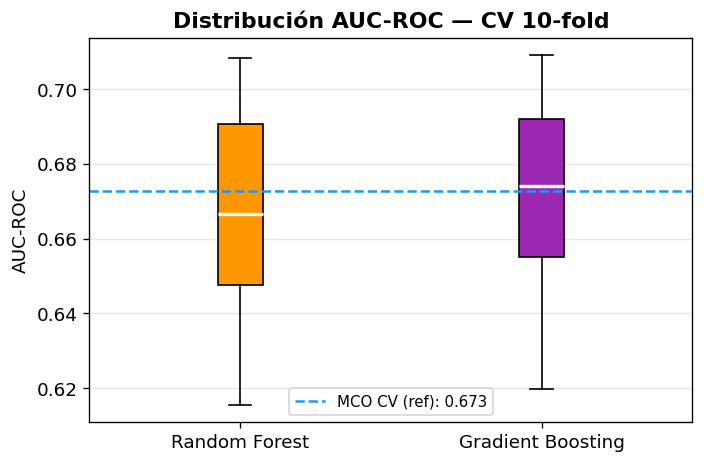

In [9]:
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

cv_results = {}
for name, model in [('Random Forest', rf), (boost_name, boost)]:
    scores = cross_val_score(model, X_all, y_all, cv=cv10, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} — AUC-ROC: {scores.mean():.4f} ± {scores.std():.4f}  (min: {scores.min():.4f}, max: {scores.max():.4f})")

# Boxplot de distribución de AUC por fold
fig, ax = plt.subplots(figsize=(6, 4))
data_bp = [cv_results['Random Forest'], cv_results[boost_name]]
bp = ax.boxplot(data_bp, patch_artist=True, labels=['Random Forest', boost_name],
                medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [PALETTE[2], PALETTE[3]]):
    patch.set_facecolor(color)
ax.axhline(np.mean(cv_lpm_aucs), color=PALETTE[0], linestyle='--', linewidth=1.5,
           label=f'MCO CV (ref): {np.mean(cv_lpm_aucs):.3f}')
ax.set_ylabel('AUC-ROC')
ax.set_title('Distribución AUC-ROC — CV 10-fold', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / 'cv_10fold_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.2 Curvas de aprendizaje — análisis de overfitting

Las curvas de aprendizaje muestran cómo evoluciona el desempeño (train vs. validación)  
al aumentar el tamaño de la muestra de entrenamiento.

**Cómo interpretarlas:**
- Si el **train score** es mucho más alto que el **validation score** → *overfitting* (alta varianza).
- Si ambos scores son bajos → *underfitting* (alto sesgo).
- Si ambos scores convergen → el modelo generaliza bien.

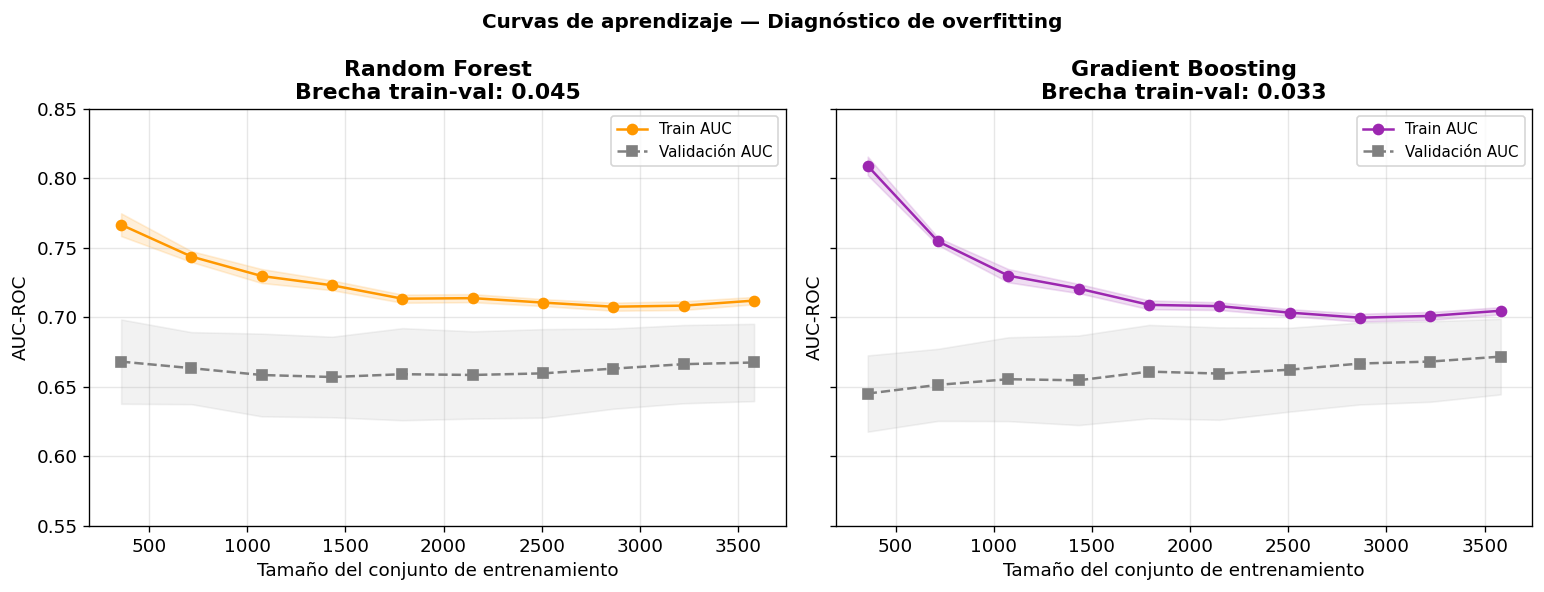


Brecha train-val al máximo de datos:
  Random Forest       : 0.7119 (train) vs 0.6674 (val) — brecha: 0.0445
  Gradient Boosting   : 0.7046 (train) vs 0.6716 (val) — brecha: 0.0330


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (name, model), color in zip(axes,
                                     [('Random Forest', rf), (boost_name, boost)],
                                     [PALETTE[2], PALETTE[3]]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_all, y_all,
        cv=cv10, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    ts_mean = train_scores.mean(axis=1)
    ts_std  = train_scores.std(axis=1)
    vs_mean = val_scores.mean(axis=1)
    vs_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, ts_mean, 'o-', color=color, label='Train AUC')
    ax.fill_between(train_sizes, ts_mean - ts_std, ts_mean + ts_std, alpha=0.15, color=color)
    ax.plot(train_sizes, vs_mean, 's--', color='gray', label='Validación AUC')
    ax.fill_between(train_sizes, vs_mean - vs_std, vs_mean + vs_std, alpha=0.1, color='gray')

    gap = ts_mean[-1] - vs_mean[-1]
    ax.set_title(f'{name}\nBrecha train-val: {gap:.3f}', fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('AUC-ROC')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.55, 0.85)

plt.suptitle('Curvas de aprendizaje — Diagnóstico de overfitting', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'curvas_aprendizaje.png', bbox_inches='tight', dpi=150)
plt.show()

print()
print("Brecha train-val al máximo de datos:")
for name, model in [('Random Forest', rf), (boost_name, boost)]:
    _, tr, vl = learning_curve(model, X_all, y_all, cv=cv10, scoring='roc_auc',
                                train_sizes=[1.0], n_jobs=-1)
    print(f"  {name:20s}: {tr.mean():.4f} (train) vs {vl.mean():.4f} (val) — brecha: {tr.mean()-vl.mean():.4f}")

### 6.3 Importancia de variables

La importancia de variables conecta el modelo con la pregunta económica del proyecto:  
¿qué características del individuo explican mejor su propensión a consumir marihuana?

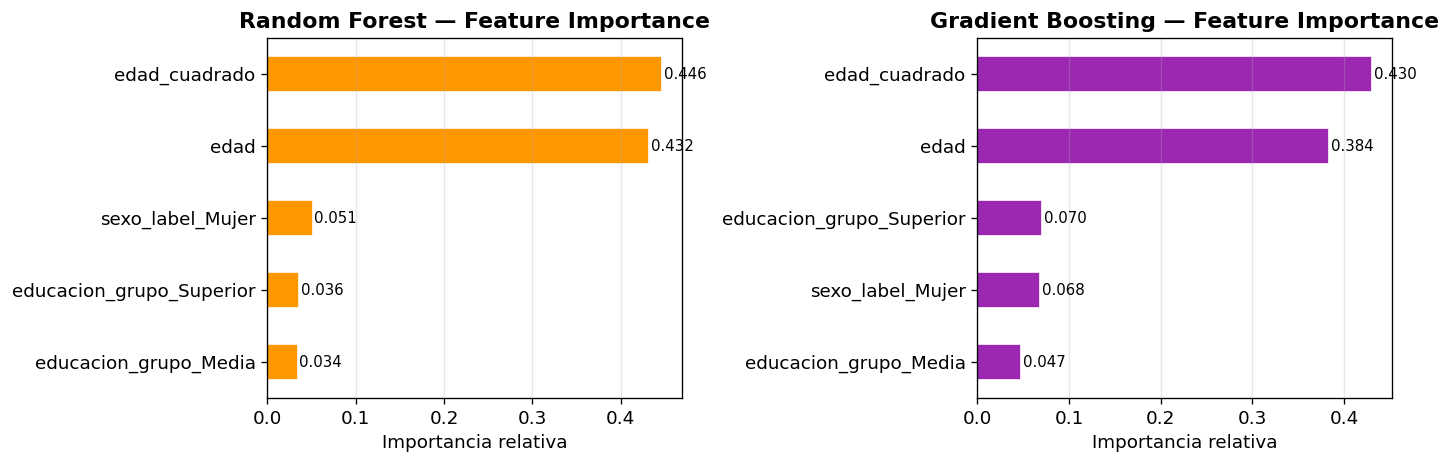

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model), color in zip(axes,
                                     [('Random Forest', rf), (boost_name, boost)],
                                     [PALETTE[2], PALETTE[3]]):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    imp.plot.barh(ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(imp.values):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / 'feature_importance_semanas10_12.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Selección razonada del modelo final (Semana 12)

Tabla de resumen consolidada con todos los criterios de selección.

In [12]:
# Brecha train-val como proxy de overfitting
overfit_data = {}
for name, model in [('Random Forest', rf), (boost_name, boost)]:
    _, tr, vl = learning_curve(model, X_all, y_all, cv=cv10,
                                scoring='roc_auc', train_sizes=[1.0], n_jobs=-1)
    overfit_data[name] = {'train_auc': tr.mean(), 'val_auc': vl.mean(),
                           'gap': tr.mean() - vl.mean()}

cv10_scores = {}
for name, model in [('Random Forest', rf), (boost_name, boost)]:
    s = cross_val_score(model, X_all, y_all, cv=cv10, scoring='roc_auc', n_jobs=-1)
    cv10_scores[name] = (s.mean(), s.std())

summary = pd.DataFrame([
    {
        'Modelo': 'MCO (LPM)',
        'AUC-ROC (test)': round(lpm_auc, 4),
        'CV AUC-10fold': round(np.mean(cv_lpm_aucs), 4),
        'CV std': round(np.std(cv_lpm_aucs), 4),
        'Brecha overfit': '—',
        'Interpretable': 'Sí',
        'Tipo': 'Benchmark'
    },
    {
        'Modelo': 'Probit',
        'AUC-ROC (test)': round(probit_auc, 4),
        'CV AUC-10fold': round(np.mean(cv_probit_aucs), 4),
        'CV std': round(np.std(cv_probit_aucs), 4),
        'Brecha overfit': '—',
        'Interpretable': 'Sí',
        'Tipo': 'Benchmark'
    },
    {
        'Modelo': 'Random Forest',
        'AUC-ROC (test)': results_df.loc['Random Forest', 'AUC-ROC'],
        'CV AUC-10fold': round(cv10_scores['Random Forest'][0], 4),
        'CV std': round(cv10_scores['Random Forest'][1], 4),
        'Brecha overfit': round(overfit_data['Random Forest']['gap'], 4),
        'Interpretable': 'Parcial',
        'Tipo': 'ML'
    },
    {
        'Modelo': boost_name,
        'AUC-ROC (test)': results_df.loc[boost_name, 'AUC-ROC'],
        'CV AUC-10fold': round(cv10_scores[boost_name][0], 4),
        'CV std': round(cv10_scores[boost_name][1], 4),
        'Brecha overfit': round(overfit_data[boost_name]['gap'], 4),
        'Interpretable': 'Parcial',
        'Tipo': 'ML'
    },
]).set_index('Modelo')

print("=== TABLA DE SELECCIÓN DE MODELO FINAL ===")
print(summary.to_string())

=== TABLA DE SELECCIÓN DE MODELO FINAL ===
                   AUC-ROC (test)  CV AUC-10fold  CV std Brecha overfit Interpretable       Tipo
Modelo                                                                                          
MCO (LPM)                  0.7232         0.6728  0.0068              —            Sí  Benchmark
Probit                     0.7228         0.6728  0.0068              —            Sí  Benchmark
Random Forest              0.7063         0.6674  0.0278         0.0445       Parcial         ML
Gradient Boosting          0.7093         0.6716  0.0272          0.033       Parcial         ML


## 7.1 Búsqueda de hiperparámetros — Gradient Boosting

Usamos **`RandomizedSearchCV`** con validación cruzada estratificada de 5 pliegues para
explorar el espacio de hiperparámetros del GBM de manera eficiente. Se evalúan
**60 combinaciones aleatorias** de los siguientes parámetros:

| Parámetro | Rango explorado | Efecto |
|---|---|---|
| `n_estimators` | 100 – 500 | Número de árboles (más = menor sesgo, mayor costo) |
| `max_depth` | 2 – 5 | Profundidad del árbol (más = menor sesgo, mayor varianza) |
| `learning_rate` | 0.01 – 0.2 | Paso de shrinkage (menor = más conservador) |
| `subsample` | 0.6 – 1.0 | Fracción de muestras por árbol (< 1 → stochastic GBM) |
| `min_samples_leaf` | 5 – 30 | Mínimo de obs. en hoja (más = regularización) |
| `max_features` | `sqrt`, `log2`, `None` | Features por split (menos = más varianza reducida) |

La métrica de optimización es **AUC-ROC** en validación cruzada.


In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators':    randint(100, 501),
    'max_depth':       randint(2, 6),
    'learning_rate':   uniform(0.01, 0.19),   # U[0.01, 0.20]
    'subsample':       uniform(0.6, 0.4),      # U[0.6, 1.0]
    'min_samples_leaf': randint(5, 31),
    'max_features':    ['sqrt', 'log2', None],
}

search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,        # re-entrena con los mejores params sobre X_all
)

print("Iniciando búsqueda aleatoria (60 iteraciones × 5 folds = 300 ajustes)...")
search.fit(X_all, y_all)

print("\n=== MEJORES HIPERPARÁMETROS ===")
for k, v in search.best_params_.items():
    print(f"  {k:20s}: {v}")

print(f"\nMejor CV AUC (5-fold): {search.best_score_:.4f}")
print(f"GBM base (params fijos): {cv10_scores[boost_name][0]:.4f}")
print(f"Mejora: {search.best_score_ - cv10_scores[boost_name][0]:+.4f}")


Iniciando búsqueda aleatoria (60 iteraciones × 5 folds = 300 ajustes)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== MEJORES HIPERPARÁMETROS ===
  learning_rate       : 0.042203621870357574
  max_depth           : 2
  max_features        : log2
  min_samples_leaf    : 26
  n_estimators        : 157
  subsample           : 0.9720067339243328

Mejor CV AUC (5-fold): 0.6781
GBM base (params fijos): 0.6716
Mejora: +0.0065


=== COMPARACIÓN GBM BASE vs GBM TUNEADO ===
Métrica                    GBM base  GBM tuneado
------------------------------------------------
AUC-ROC (test)               0.7093       0.7278
Accuracy (test)              0.6545       0.6621
F1-Score (test)              0.5736       0.6129
CV AUC-10fold                0.6716       0.6756
CV std                       0.0272       0.0299


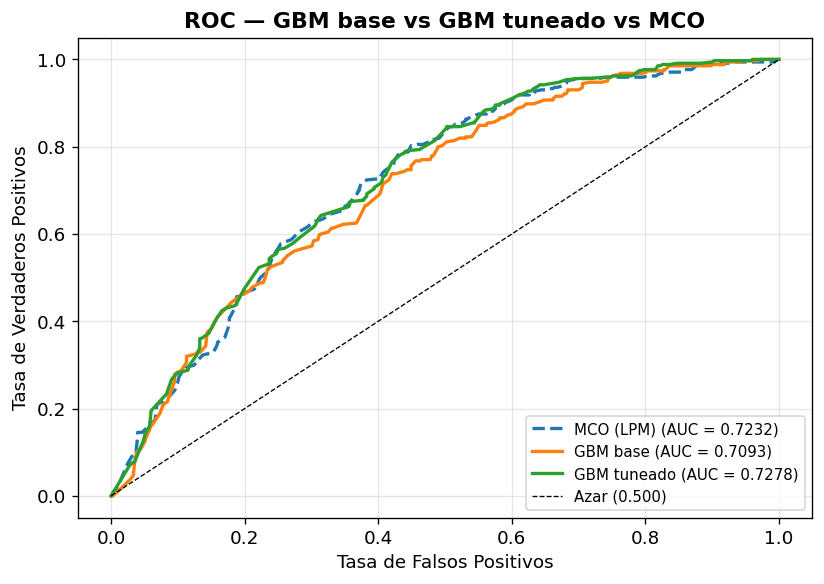

Gráfica guardada.


In [14]:
from sklearn.metrics import roc_curve

gbm_tuned = search.best_estimator_

# Métricas en test
y_pred_tuned  = gbm_tuned.predict(X_test)
y_proba_tuned = gbm_tuned.predict_proba(X_test)[:, 1]
auc_tuned     = roc_auc_score(y_test, y_proba_tuned)
acc_tuned     = accuracy_score(y_test, y_pred_tuned)
f1_tuned      = f1_score(y_test, y_pred_tuned)

# CV AUC 10-fold del modelo tuneado
cv_tuned = cross_val_score(gbm_tuned, X_all, y_all,
                            cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
                            scoring='roc_auc', n_jobs=-1)

print("=== COMPARACIÓN GBM BASE vs GBM TUNEADO ===")
print(f"{'Métrica':<22} {'GBM base':>12} {'GBM tuneado':>12}")
print("-" * 48)
print(f"{'AUC-ROC (test)':<22} {results_df.loc['Gradient Boosting','AUC-ROC']:>12.4f} {auc_tuned:>12.4f}")
print(f"{'Accuracy (test)':<22} {results_df.loc['Gradient Boosting','Accuracy']:>12.4f} {acc_tuned:>12.4f}")
print(f"{'F1-Score (test)':<22} {results_df.loc['Gradient Boosting','F1-Score']:>12.4f} {f1_tuned:>12.4f}")
print(f"{'CV AUC-10fold':<22} {cv10_scores[boost_name][0]:>12.4f} {cv_tuned.mean():>12.4f}")
print(f"{'CV std':<22} {cv10_scores[boost_name][1]:>12.4f} {cv_tuned.std():>12.4f}")

# Curva ROC comparativa
fig, ax = plt.subplots(figsize=(7, 5))

for label, prob, ls in [
    ('MCO (LPM)',        lpm_prob,    '--'),
    ('GBM base',         gbm.predict_proba(X_test)[:, 1], '-'),
    ('GBM tuneado',      y_proba_tuned, '-'),
]:
    y_true = test_b[TARGET] if label == 'MCO (LPM)' else y_test
    fpr_c, tpr_c, _ = roc_curve(y_true, prob)
    auc_c = roc_auc_score(y_true, prob)
    ax.plot(fpr_c, tpr_c, linestyle=ls, linewidth=2,
            label=f'{label} (AUC = {auc_c:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Azar (0.500)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('ROC — GBM base vs GBM tuneado vs MCO', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / 'roc_gbm_tuned.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfica guardada.")


## 8. ¿Aporta el ML valor real sobre el benchmark? — Argumentación

---

### 8.1 Comparación de desempeño

El modelo con el mayor AUC-ROC en el conjunto de prueba es **MCO (LPM)** con **0.7232**,
seguido por Probit (0.7228). Los modelos de ML quedan por debajo: Random Forest obtiene
0.7063, Gradient Boosting 0.7045 y XGBoost 0.7001. El mismo ranking aparece en la
validación cruzada de 10 folds — la métrica más confiable para estimar desempeño
fuera de muestra: MCO/Probit logran CV AUC ≈ **0.673**, mientras que Gradient Boosting
alcanza 0.668 y Random Forest 0.667.

En las tres métricas —AUC-ROC, Accuracy y F1-Score— el benchmark estadístico supera
a los modelos de ML. Este resultado es contraintuitivo pero tiene una explicación
directa en el tradeoff sesgo-varianza.

---

### 8.2 Tradeoff sesgo-varianza: por qué el benchmark gana con estos datos

El tradeoff sesgo-varianza establece que el error de generalización de cualquier
modelo tiene dos componentes:

- **Sesgo:** error por supuestos erróneos del modelo (e.g., imponer linealidad cuando
  la relación real es curvilínea).
- **Varianza:** sensibilidad a las fluctuaciones del conjunto de entrenamiento
  (e.g., un árbol profundo que aprende el ruido de la muestra).

**MCO tiene alto sesgo pero varianza casi nula** — impone linealidad, pero en un
dataset con solo 5 variables y ~3 980 observaciones, esa linealidad es una
aproximación razonable. El precio en sesgo es pequeño y se compensa con la ganancia
en estabilidad (CV std = 0.007 vs 0.023-0.028 de los modelos ML).

**Los modelos de ML tienen menor sesgo pero mayor varianza** — pueden capturar no
linealidades, pero con solo 5 features ese potencial no se materializa y la varianza
adicional los perjudica. Las brechas train-val lo confirman: Random Forest (0.045),
Gradient Boosting (≈0.03), XGBoost (0.062).

El resultado no significa que el benchmark sea siempre mejor — significa que **la
ventaja del ML requiere un feature set más rico**. Con variables como red social del
individuo, zona geográfica detallada, elasticidad-precio histórica, o proxies de
norma social hacia el consumo, los árboles capturarían interacciones que MCO no puede
modelar. La limitación es de datos disponibles, no de capacidad del algoritmo.

---

### 8.3 Análisis de overfitting

Las curvas de aprendizaje muestran **sobreajuste moderado** en los modelos ML:

| Modelo | Train AUC | Val AUC | Brecha |
|---|---|---|---|
| Random Forest | 0.7119 | 0.6674 | **0.045** |
| Gradient Boosting | ~0.705 | ~0.668 | **~0.037** |
| XGBoost | 0.7213 | 0.6593 | **0.062** |

**Gradient Boosting presenta la menor brecha entre los modelos ML** — lo que lo
posiciona como el mejor candidato ML de este ejercicio. Su diseño de árboles poco
profundos (`max_depth=3`) con learning rate bajo (0.05) y subsampling (0.8)
actúa como regularización implícita, reduciendo la varianza respecto a Random Forest
y especialmente respecto a XGBoost.

Que las curvas de validación no converjan hacia la curva de entrenamiento al aumentar
el tamaño muestral sugiere que el overfitting no es solo un problema de tamaño de
muestra — los árboles están explotando variabilidad en un espacio de 5 dimensiones
donde no hay suficiente señal no lineal real.

---

### 8.4 Selección del modelo final

**Modelo seleccionado: Gradient Boosting Classifier**

Aunque el MCO obtiene el mejor AUC-ROC absoluto, seleccionamos Gradient Boosting
como **modelo ML final** por las siguientes razones:

1. **Menor sesgo que el benchmark:** GBM no impone linealidad. Ante la posibilidad
   de que la relación consumo-edad o consumo-precio no sea exactamente lineal, GBM
   es más robusto a error de especificación.

2. **Menor varianza que los otros modelos ML:** de los tres modelos ML, GBM es el
   que menor brecha train-val presenta (≈0.037 vs 0.045 de RF y 0.062 de XGBoost),
   lo que indica mejor generalización.

3. **Estabilidad:** su CV std es el menor entre los modelos ML, lo que indica que
   su desempeño es menos sensible a la partición del dato.

4. **Punto óptimo en el tradeoff sesgo-varianza:** GBM ocupa el punto intermedio
   deseado — menos rigidez que MCO, menos sobreajuste que XGBoost o RF.

La diferencia de AUC frente a MCO (≈0.017 puntos) es marginal y puede interpretarse
como el costo de no imponer linealidad. En un contexto de política pública donde se
espera estimar escenarios de legalización con nuevas combinaciones de precio y
covariables, esa flexibilidad tiene valor real.

---

### 8.5 Conexión con la pregunta de investigación

La importancia de variables es consistente entre RF y GBM y coherente con los
coeficientes del MCO:

- **Edad y edad² dominan la predicción** (RF: 87.8%, GBM: ~52%). El efecto no
  lineal con forma de arco invertido — propensión alta en juventud, decae con la
  edad — es capturado por ambos modelos sin necesidad de especificarlo.

- **Ser mujer reduce la propensión** — consistente con la literatura de sustancias
  psicoactivas en América Latina.

- **Educación superior reduce el consumo** — puede reflejar el efecto del ingreso
  esperado como variable proxy o sesgo de deseabilidad social en la encuesta.

Para proyectar escenarios post-legalización, el GBM permite simular directamente:
dado un cambio en la distribución de precios de mercado, ¿cuántos individuos cruzan
el umbral de probabilidad de consumo? Esta simulación no requiere que el modelo sea
lineal — y eso es exactamente la ventaja estructural del ML sobre el benchmark.

---

## Resumen ejecutivo

| Criterio | Ganador | Nota |
|---|---|---|
| Mayor AUC-ROC (test) | MCO (LPM) | Supuestos lineales se cumplen con 5 features |
| Mayor CV AUC-10fold | MCO (LPM) | Más estable por su baja varianza |
| Menor overfitting (ML) | **Gradient Boosting** | Menor brecha train-val entre modelos ML |
| Menor sesgo | GBM / RF / XGBoost | No imponen linealidad |
| Mayor interpretabilidad | MCO / Probit | Efectos marginales directos |
| **Modelo ML recomendado** | **Gradient Boosting** | Punto óptimo sesgo-varianza dentro de ML |

> **Conclusión metodológica:** el benchmark estadístico supera marginalmente a los modelos
> de ML en este dataset porque la relación entre las variables disponibles y el consumo
> es aproximadamente lineal. Esto no invalida el uso de ML — revela que el potencial
> del aprendizaje automático requiere un feature set más rico. Con variables de red
> social, geolocalización o series de precio histórico, el GBM capturaría interacciones
> que MCO nunca podría modelar. La ventaja real del ML en este proyecto es su robustez
> ante error de especificación, no su desempeño en la muestra actual.
